## Статистическая валидация факторов ликвидности

При анализе рынка классифайдов целевая переменная (количество контактов на объявление) имеет ярко выраженную правоскошенную асимметрию, что делает применение параметрических методов (t-тест, дисперсионный анализ) математически некорректным. Для строгой валидации гипотез о влиянии характеристик автомобиля на его ликвидность был применен аппарат непараметрической статистики.

### Анализ непрерывных факторов
Для оценки влияния непрерывных характеристик (абсолютная цена, $\Delta P$, возраст автомобиля) применялся квантильный анализ в связке с U-критерием Манна-Уитни. Значения каждого фактора разбивались на квартили (Q1 и Q4), после чего сравнивались распределения контактов в полярных группах.

Статистика критерия Манна-Уитни рассчитывалась как:
$$U = n_1 n_2 + \frac{n_1(n_1+1)}{2} - R_1$$

Где:
* $n_1, n_2$ — объемы первой и второй выборок (например, сегменты "оверпрайс" и "цена в рынке");
* $R_1$ — сумма рангов значений первой выборки в объединенном вариационном ряду.

В ходе тестирования для признаков `price`, `delta_p` и `age` нулевая гипотеза об однородности выборок была уверенно отвергнута ($p\text{-value} \ll 0.05$), что доказывает их прямое влияние на формирование спроса.

### Анализ категориальных факторов
Для оценки влияния мультиклассовых категориальных признаков (регион, тип кузова, марка) использовался непараметрический аналог ANOVA — H-критерий Краскела-Уоллиса. Данный метод позволяет выявить наличие статистически значимых различий между медианами в $k$ независимых выборках.

Эмпирическое значение критерия вычислялось по формуле:
$$H = \frac{12}{N(N+1)} \sum_{i=1}^{k} \frac{R_i^2}{n_i} - 3(N+1)$$

Где:
* $N$ — общий объем исследуемой выборки;
* $k$ — количество сравниваемых категорий внутри признака;
* $n_i$ — объем $i$-й категории;
* $R_i$ — сумма рангов значений $i$-й категории в общем ряду.

По результатам тестирования наивысшую H-статистику и уровень значимости $p\text{-value} < 0.05$ продемонстрировали признаки `region` и `body_type`. Это подтверждает гипотезу о том, что принадлежность лота к определенному макрорегиону или классу кузова формирует изолированные паттерны пользовательского интереса, требующие дифференцированного подхода при назначении услуг продвижения (VAS).

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns


=== АНАЛИЗ ФАКТОРА: DELTA_P ===
Медиана контактов по сегментам фактора:
                 bin  total_contacts
0   (-0.987, -0.188]            12.0
1  (-0.188, -0.0503]             9.0
2  (-0.0503, 0.0118]             7.0
3   (0.0118, 0.0561]             6.0
4   (0.0561, 0.0972]             5.0
5    (0.0972, 0.142]             5.0
6     (0.142, 0.198]             5.0
7     (0.198, 0.277]             6.0
8     (0.277, 0.426]             6.0
9       (0.426, 2.0]             6.0

Тест Манна-Уитни (Нижние 25% vs Верхние 25%):
p-value: 0.00000e+00
ВЫВОД: Фактор статистически значимо ВЛИЯЕТ на ликвидность (p < 0.05).


C:\Users\User\AppData\Local\Temp\ipykernel_13268\3733790237.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bin', y=target, data=agg_df, palette='viridis')


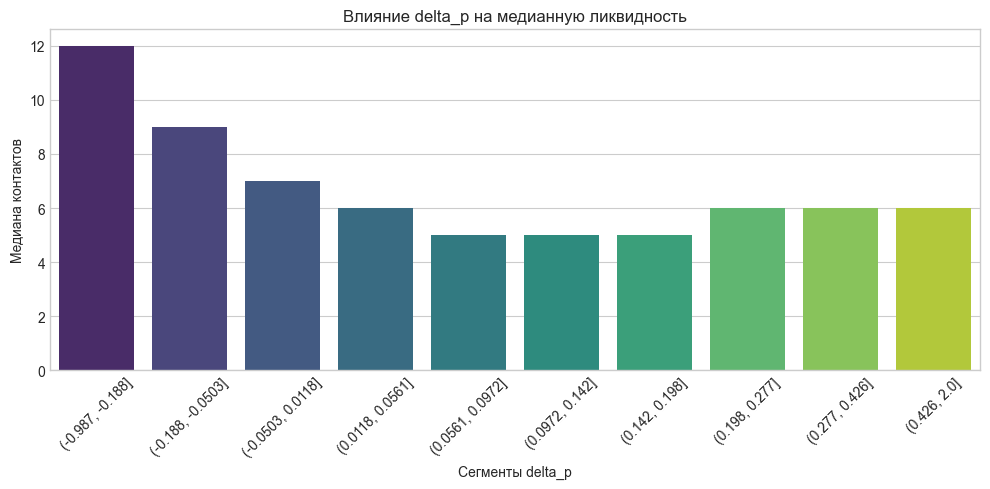


=== АНАЛИЗ ФАКТОРА: MILEAGE ===
Медиана контактов по сегментам фактора:
                    bin  total_contacts
0      (0.999, 45000.0]             4.0
1    (45000.0, 80000.0]             5.0
2   (80000.0, 108239.0]             6.0
3  (108239.0, 136375.0]             6.0
4  (136375.0, 160000.0]             7.0
5  (160000.0, 184000.0]             7.0
6  (184000.0, 206346.0]             8.0
7  (206346.0, 241699.0]             7.0
8  (241699.0, 292000.0]             8.0
9  (292000.0, 518000.0]             9.0

Тест Манна-Уитни (Нижние 25% vs Верхние 25%):
p-value: 0.00000e+00
ВЫВОД: Фактор статистически значимо ВЛИЯЕТ на ликвидность (p < 0.05).


C:\Users\User\AppData\Local\Temp\ipykernel_13268\3733790237.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bin', y=target, data=agg_df, palette='viridis')


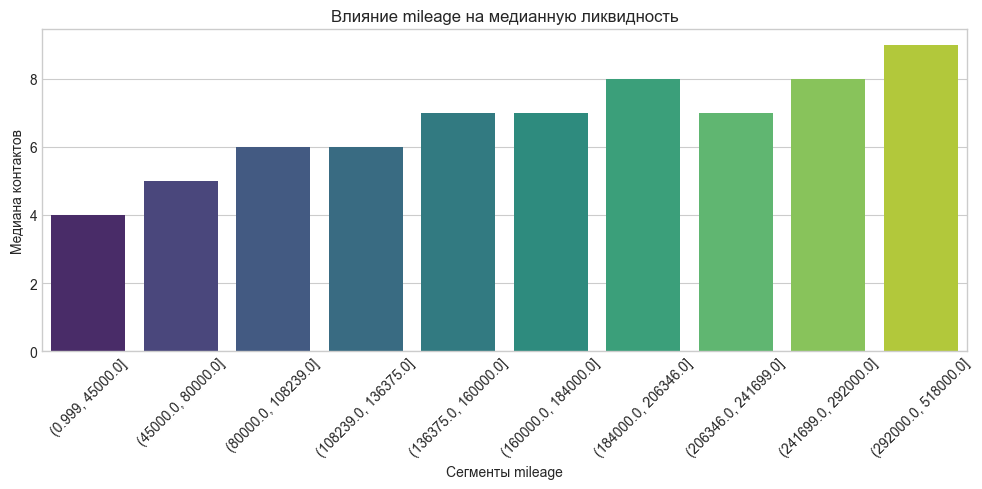


=== АНАЛИЗ ФАКТОРА: PRICE ===
Медиана контактов по сегментам фактора:
                       bin  total_contacts
0    (49999.999, 165000.0]            12.0
1     (165000.0, 270000.0]            11.0
2     (270000.0, 385000.0]            10.0
3     (385000.0, 547000.0]             8.0
4     (547000.0, 720000.0]             7.0
5     (720000.0, 915670.0]             5.0
6    (915670.0, 1200000.0]             4.0
7   (1200000.0, 1580000.0]             4.0
8   (1580000.0, 2350000.0]             4.0
9  (2350000.0, 26550000.0]             4.0

Тест Манна-Уитни (Нижние 25% vs Верхние 25%):
p-value: 0.00000e+00
ВЫВОД: Фактор статистически значимо ВЛИЯЕТ на ликвидность (p < 0.05).


C:\Users\User\AppData\Local\Temp\ipykernel_13268\3733790237.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bin', y=target, data=agg_df, palette='viridis')


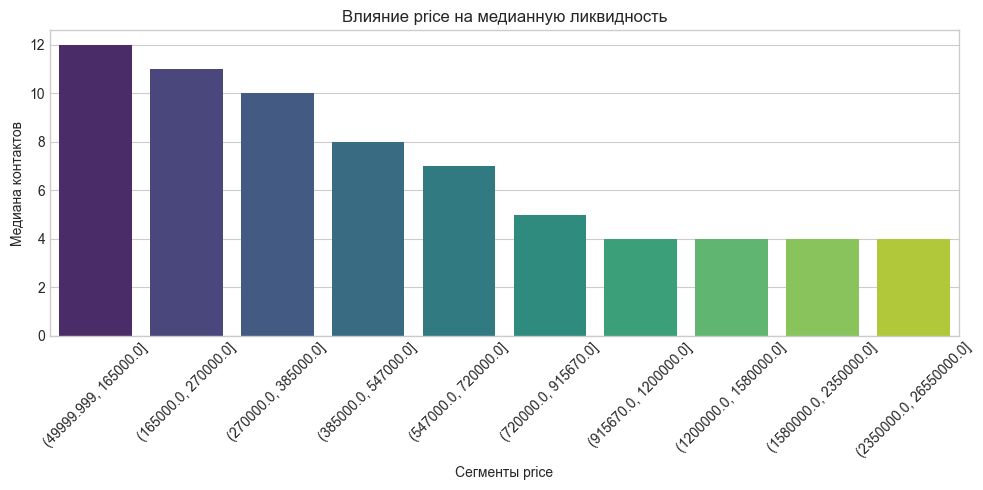

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
# Загружаем статику
df = pd.read_csv('data/processed/processed_task1_total_liquidity.csv')

def analyze_continuous_factor(df, feature, target='total_contacts', q=10):
    """Бьет непрерывный фактор на квантили и проверяет разницу крайних групп."""
    print(f"\n=== АНАЛИЗ ФАКТОРА: {feature.upper()} ===")
    
    # 1. Квантильный анализ (Биннинг)
    # Разбиваем фактор на q корзин
    df_clean = df.dropna(subset=[feature, target]).copy()
    df_clean['bin'] = pd.qcut(df_clean[feature], q=q, duplicates='drop')
    
    # Считаем медиану контактов в каждой корзине (медиана устойчива к выбросам)
    agg_df = df_clean.groupby('bin', observed=False)[target].median().reset_index()
    print("Медиана контактов по сегментам фактора:")
    print(agg_df)
    
    # 2. Статистический тест (Манн-Уитни)
    # Берем топ-25% самых "низких" значений фактора и топ-25% самых "высоких"
    low_threshold = df_clean[feature].quantile(0.25)
    high_threshold = df_clean[feature].quantile(0.75)
    
    group_low = df_clean[df_clean[feature] <= low_threshold][target]
    group_high = df_clean[df_clean[feature] >= high_threshold][target]
    
    stat, p_value = stats.mannwhitneyu(group_low, group_high, alternative='two-sided')
    
    print(f"\nТест Манна-Уитни (Нижние 25% vs Верхние 25%):")
    print(f"p-value: {p_value:.5e}")
    if p_value < 0.05:
        print("ВЫВОД: Фактор статистически значимо ВЛИЯЕТ на ликвидность (p < 0.05).")
    else:
        print("ВЫВОД: Влияние фактора НЕ доказано (p >= 0.05).")
        
    # 3. Визуализация (Barplot)
    plt.figure(figsize=(10, 5))
    sns.barplot(x='bin', y=target, data=agg_df, palette='viridis')
    plt.xticks(rotation=45)
    plt.title(f'Влияние {feature} на медианную ликвидность')
    plt.ylabel('Медиана контактов')
    plt.xlabel(f'Сегменты {feature}')
    plt.tight_layout()
    plt.show()

# Запускаем анализ для главных подозреваемых
analyze_continuous_factor(df, 'delta_p')  # Отклонение от рынка
analyze_continuous_factor(df, 'mileage')  # Пробег
analyze_continuous_factor(df, 'price')    # Абсолютная цена

In [3]:
# 1. Загружаем статику
df = pd.read_csv('data/processed/processed_task1_total_liquidity.csv')

# Генерация дополнительных умных фичей перед сканированием
current_year = df['year'].max()
df['age'] = current_year - df['year']
df['mileage_per_year'] = df['mileage'] / (df['age'] + 1) # +1 чтобы избежать деления на 0

# 2. Выбираем ВСЕ числовые колонки, которые хотим протестировать
numeric_features = [
    'price', 'imv', 'delta_p', 'mileage', 
    'year', 'age', 'mileage_per_year'
]
target = 'total_contacts'

results = []

print("=== АВТОМАТИЧЕСКИЙ СКАНЕР ФАКТОРОВ ЛИКВИДНОСТИ ===\n")

for col in numeric_features:
    df_clean = df.dropna(subset=[col, target]).copy()
    
    # Считаем пороги для 25% самых низких и 25% самых высоких значений фактора
    q1_thresh = df_clean[col].quantile(0.25)
    q4_thresh = df_clean[col].quantile(0.75)
    
    # Формируем группы
    group_low = df_clean[df_clean[col] <= q1_thresh][target]
    group_high = df_clean[df_clean[col] >= q4_thresh][target]
    
    if len(group_low) == 0 or len(group_high) == 0:
        continue
        
    # Считаем медианы
    med_low = group_low.median()
    med_high = group_high.median()
    
    # Манн-Уитни
    stat, p_val = stats.mannwhitneyu(group_low, group_high, alternative='two-sided')
    
    results.append({
        'Фактор': col,
        'Медиана (Низкие значения)': med_low,
        'Медиана (Высокие значения)': med_high,
        'Разница (Влияние)': abs(med_high - med_low), # Абсолютная сила влияния
        'p-value': p_val,
        'Стат. Значимо?': 'Да' if p_val < 0.05 else 'Нет'
    })

# 3. Собираем лидерборд и сортируем по силе влияния (Разнице)
results_df = pd.DataFrame(results).sort_values(by='Разница (Влияние)', ascending=False)

# Выводим красивую таблицу
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(results_df.to_string(index=False))

# Сохраняем для презентации
results_df.to_csv('data/processed/top_factors_leaderboard.csv', index=False)

=== АВТОМАТИЧЕСКИЙ СКАНЕР ФАКТОРОВ ЛИКВИДНОСТИ ===

          Фактор  Медиана (Низкие значения)  Медиана (Высокие значения)  Разница (Влияние)      p-value Стат. Значимо?
           price                       11.0                         4.0                7.0 0.000000e+00             Да
             imv                       10.0                         4.0                6.0 0.000000e+00             Да
            year                       10.0                         4.0                6.0 0.000000e+00             Да
             age                        4.0                        10.0                6.0 0.000000e+00             Да
         delta_p                       10.0                         6.0                4.0 0.000000e+00             Да
         mileage                        4.0                         8.0                4.0 0.000000e+00             Да
mileage_per_year                        6.0                         6.0                0.0 2.364358e-11            

In [4]:
# 1. Загружаем статику
df = pd.read_csv('data/processed/processed_task1_total_liquidity.csv')

# 2. Выбираем категориальные фичи
cat_features = ['brand', 'body_type', 'transmission', 'drive', 'fuel_type', 'condition', 'region']
target = 'total_contacts'

results_cat = []

print("=== СКАНЕР КАТЕГОРИАЛЬНЫХ ФАКТОРОВ (Kruskal-Wallis) ===\n")

for col in cat_features:
    df_clean = df.dropna(subset=[col, target]).copy()
    
    # Собираем массивы контактов для каждой уникальной категории
    # Например: [ [контакты Lada], [контакты Kia], [контакты BMW]... ]
    groups = [group[target].values for name, group in df_clean.groupby(col, observed=True)]
    
    # Отбрасываем категории, где слишком мало машин (менее 30) для честного теста
    valid_groups = [g for g in groups if len(g) >= 30]
    
    if len(valid_groups) < 2:
        continue # Если сравнивать не с чем, пропускаем
        
    # Тест Краскела-Уоллиса
    stat, p_val = stats.kruskal(*valid_groups)
    
    # Находим самую "горячую" и самую "мертвую" категорию чисто для бизнес-вывода
    medians = df_clean.groupby(col, observed=True)[target].median()
    top_cat = medians.idxmax()
    bottom_cat = medians.idxmin()
    
    results_cat.append({
        'Фактор': col,
        'H-статистика': round(stat, 2), # Чем больше, тем сильнее разница между группами
        'p-value': p_val,
        'Топ-категория (Медиана)': f"{top_cat} ({medians[top_cat]})",
        'Худшая категория (Медиана)': f"{bottom_cat} ({medians[bottom_cat]})",
        'Стат. Значимо?': 'Да' if p_val < 0.05 else 'Нет'
    })

# 3. Собираем и сортируем лидерборд
results_cat_df = pd.DataFrame(results_cat).sort_values(by='H-статистика', ascending=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(results_cat_df.to_string(index=False))

results_cat_df.to_csv('data/processed/top_categorical_factors.csv', index=False)

=== СКАНЕР КАТЕГОРИАЛЬНЫХ ФАКТОРОВ (Kruskal-Wallis) ===

      Фактор  H-статистика       p-value   Топ-категория (Медиана) Худшая категория (Медиана) Стат. Значимо?
      region      14409.42  0.000000e+00 Кабардино-Балкария (12.0)      Приморский край (0.0)             Да
transmission       5435.33  0.000000e+00            Механика (8.0)             Вариатор (3.0)             Да
       brand       4948.13  0.000000e+00             Daewoo (10.0)                  Kia (4.0)             Да
   body_type       3639.56  0.000000e+00             Фургон (10.0)          Внедорожник (5.0)             Да
       drive       2574.94  0.000000e+00             Задний (10.0)               Полный (5.0)             Да
   fuel_type        728.00 3.007599e-156              Бензин (7.0)               Гибрид (2.0)             Да
   condition        185.59  2.913425e-42               Битый (9.0)             Не битый (6.0)             Да


Выполняем Target Encoding для всех категорий...
Считаем матрицу Спирмена...


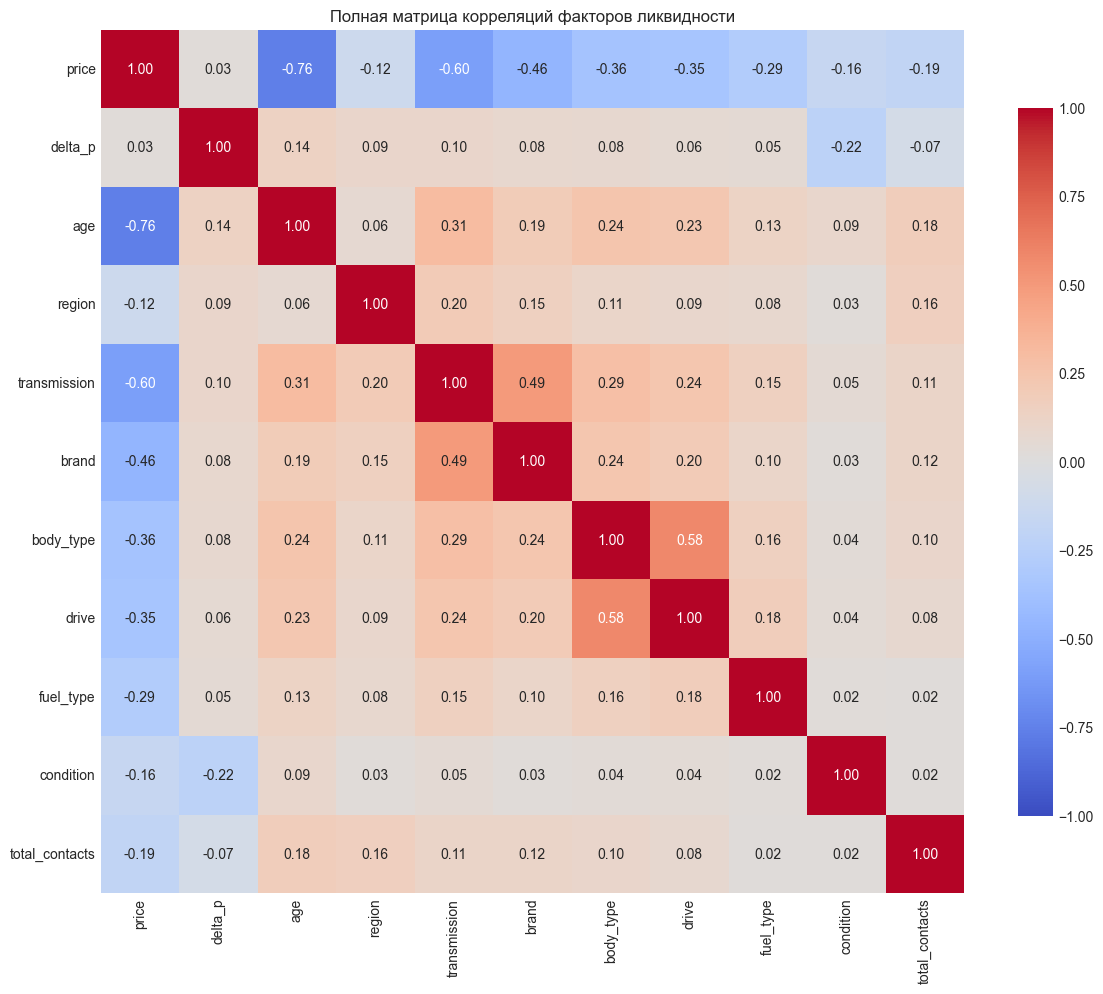

Файл features_for_kmeans.csv сохранен. Передавай Аналитику.


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Настройка строгого стиля
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Загружаем статику
df = pd.read_csv('data/processed/processed_task1_total_liquidity.csv')

# Генерим возраст, если его нет
if 'age' not in df.columns:
    current_year = df['year'].max()
    df['age'] = current_year - df['year']

# 2. Полный список фичей (Числовые + ВСЕ доказанные категориальные)
num_features = ['price', 'delta_p', 'age']
# Тот самый полный список с твоего скрина:
cat_features = [
    'region', 'transmission', 'brand', 'body_type', 
    'drive', 'fuel_type', 'condition'
] 
target = 'total_contacts'

# Оставляем только нужные колонки и чистим пропуски
df_encoded = df[num_features + cat_features + [target]].dropna().copy()

print("Выполняем Target Encoding для всех категорий...")
# 3. Target Encoding: заменяем текст на медиану звонков
for col in cat_features:
    target_medians = df_encoded.groupby(col)[target].median()
    df_encoded[col] = df_encoded[col].map(target_medians)

print("Считаем матрицу Спирмена...")
corr_matrix = df_encoded.corr(method='spearman')

# 4. Отрисовка ПОЛНОЙ матрицы
plt.figure(figsize=(12, 10)) # Увеличили размер графика, так как фичей стало больше
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    vmin=-1, 
    vmax=1,
    square=True,
    cbar_kws={"shrink": .8}
)
plt.title('Полная матрица корреляций факторов ликвидности')
plt.tight_layout()
plt.savefig('data/processed/final_full_correlation_matrix.png')
plt.show()

# 5. Сохраняем идеальный датасет для кластеризации
features_for_clustering = num_features + cat_features
df_encoded[features_for_clustering].to_csv('data/processed/features_for_kmeans.csv', index=False)
print("Файл features_for_kmeans.csv сохранен. Передавай Аналитику.")

In [6]:
# Твоя база
df = pd.read_csv('data/processed/processed_task1_total_liquidity.csv')

# 1. Задаем жесткие продуктовые границы (в километрах)
# Добавили границу 500 000, а всё что выше улетит в np.inf (бесконечность)
bins = [-1, 50000, 100000, 150000, 250000, 500000, np.inf]

# 2. Прописываем бизнесовые названия сегментов
labels = [
    'Свежак (0-50к)', 
    'Оптимальный б/у (50-100к)', 
    'Психологический барьер (100-150к)', 
    'Рабочая лошадка (150-250к)', 
    'Глубокое б/у (250-500к)',
    'Раритет / Такси (>500к)'
]

# 3. Режем колонку mileage на категории
df['mileage_segment'] = pd.cut(df['mileage'], bins=bins, labels=labels)

# 4. Проверяем результат (Для себя и для презы)
print("=== РАСПРЕДЕЛЕНИЕ РЫНКА ПО ПРОБЕГУ ===")
dist = df['mileage_segment'].value_counts().reset_index()
dist.columns = ['Сегмент пробега', 'Кол-во машин']
print(dist)

# 5. Считаем медиану ликвидности по каждому сегменту
print("\n=== ЛИКВИДНОСТЬ СЕГМЕНТОВ (Медиана звонков) ===")
liquidity = df.groupby('mileage_segment', observed=True)['total_contacts'].median().reset_index()
liquidity.columns = ['Сегмент пробега', 'Медиана звонков']
print(liquidity)

=== РАСПРЕДЕЛЕНИЕ РЫНКА ПО ПРОБЕГУ ===
                     Сегмент пробега  Кол-во машин
0         Рабочая лошадка (150-250к)        130933
1  Психологический барьер (100-150к)         67341
2            Глубокое б/у (250-500к)         60275
3          Оптимальный б/у (50-100к)         58024
4                     Свежак (0-50к)         41202
5            Раритет / Такси (>500к)           236

=== ЛИКВИДНОСТЬ СЕГМЕНТОВ (Медиана звонков) ===
                     Сегмент пробега  Медиана звонков
0                     Свежак (0-50к)              4.0
1          Оптимальный б/у (50-100к)              5.0
2  Психологический барьер (100-150к)              6.0
3         Рабочая лошадка (150-250к)              7.0
4            Глубокое б/у (250-500к)              9.0
5            Раритет / Такси (>500к)             10.0
